4.4.0
cuda


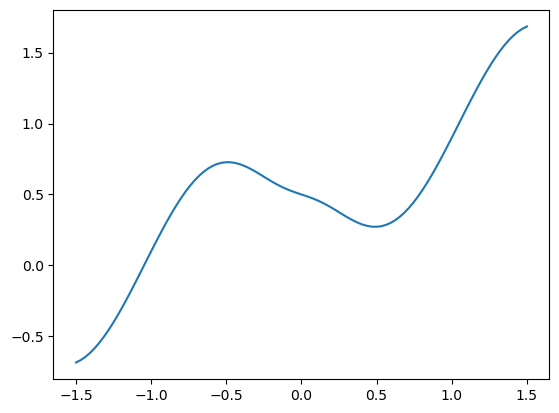

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import optuna
from models import CondSM

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

state_dict = torch.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_uni_2/sm_uni_MSE.pth", weights_only=False, map_location='cpu')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])
model.eval()

#print(model)

def target_function(t: torch.Tensor):
    N = t.shape[0]
    return -0.7*torch.sin(3*t) + torch.sigmoid(7*t)

def mse_loss(x: torch.Tensor, y: torch.Tensor):

    N = x.shape[0]
    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse
x = torch.linspace(-1.5, 1.5, 100)
plt.plot(x, target_function(x))

In [5]:
n = 100
min_voltage = -1.5
max_voltage = 1.5
vs = torch.linspace(min_voltage, max_voltage, n)
target = target_function(vs).unsqueeze(1)
#plt.plot(vs, target)
#vs = torch.linspace(-1.5, 1.5, n).unsqueeze(1)
#control_volts = torch.tensor([0.0,  0.2, -0.6, -0.8,  1.5,  1.1]).expand(n, -1)
#print(control_volts)
#input = torch.cat([vs, control_volts], axis=-1)
#print(input)

#currents = model(input).detach().cpu()
#currents_norm = (currents - currents.mean()) / currents.std()

#any_func = target_function(vs)
#any_func_norm = (any_func - any_func.mean()) / any_func.std()

#plt.scatter(vs, currents_norm)
#plt.scatter(vs, any_func_norm)

model.eval()
PRINT_EVERY = 100

def objective(trial):

    cv_list = [trial.suggest_float(f"x_{i}", min_voltage, max_voltage) for i in range(6)]

    cv_tensor = torch.tensor(cv_list, dtype=torch.float32)
    #print(cv_tensor.shape)
    v_input = torch.linspace(min_voltage, max_voltage, n).unsqueeze(1)
    #print(v_input.shape)
    cv_input = cv_tensor.expand(n, -1)
    #print(cv_input.shape)
    input_tensor = torch.cat([v_input, cv_input], dim=-1)
    #print(input_tensor.shape)
    with torch.no_grad():
        y_pred = model(input_tensor).detach().cpu()
    #print(y_pred.shape)

    mse = mse_loss(y_pred, target)
    if trial.number % PRINT_EVERY == 0:
        print('\x1b[6;30;42m' + f'{trial.number}] Finished with score: {mse: .6f}' + '\x1b[0m')

    return mse

tpe = optuna.samplers.TPESampler(multivariate=True, group=True, n_startup_trials=500)
study = optuna.create_study(direction="minimize", sampler=tpe)
study.optimize(objective, n_trials=2000)

0] Finished with score:  0.465499
100] Finished with score:  0.510613
200] Finished with score:  0.503215
300] Finished with score:  0.489647
400] Finished with score:  0.514763
500] Finished with score:  0.469787
600] Finished with score:  0.461982
700] Finished with score:  0.445357
800] Finished with score:  0.438550
900] Finished with score:  0.444826
1000] Finished with score:  0.439245
1100] Finished with score:  0.440995
1200] Finished with score:  0.442924
1300] Finished with score:  0.438772
1400] Finished with score:  0.437733
1500] Finished with score:  0.466600
1600] Finished with score:  0.442330
1700] Finished with score:  0.440542
1800] Finished with score:  0.445755
1900] Finished with score:  0.438392


In [16]:
print(study.best_trial.params)
best_v = []
for k in study.best_trial.params.keys():
    best_v.append(study.best_trial.params[k])    
print(best_v)

{'x_0': -1.496828399286754, 'x_1': -0.773345722971119, 'x_2': -1.0038206960696492, 'x_3': 0.13320106953666214, 'x_4': -1.4435129086936542, 'x_5': 0.686864273233392}
[-1.496828399286754, -0.773345722971119, -1.0038206960696492, 0.13320106953666214, -1.4435129086936542, 0.686864273233392]


tensor([-0.6242,  1.2328,  0.0793, -1.3250,  0.4238,  0.7747])


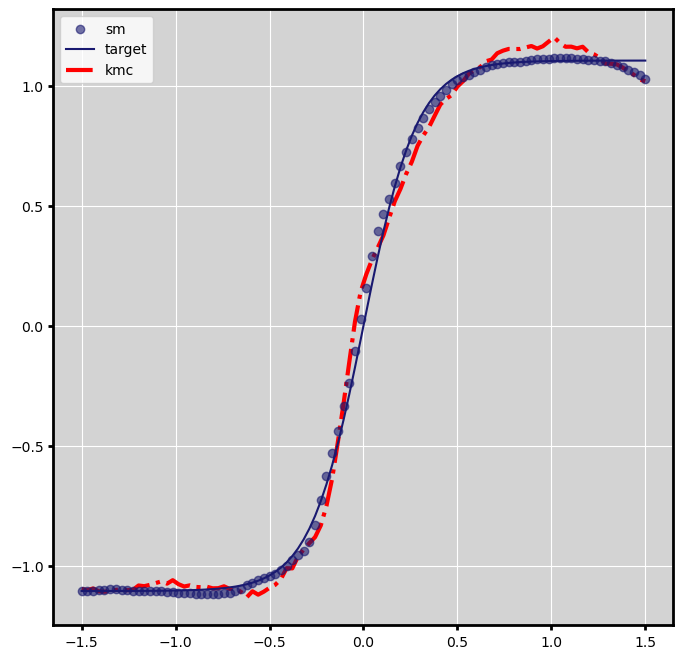

In [13]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances, plot_slice

best_trial = study.best_trial
#print(best_trial)
best_volts_list = [best_trial.params[f"x_{i}"] for i in range(6)]
best_volts = torch.tensor(best_volts_list, dtype=torch.float32)
print(best_volts)
best_volts_exp = best_volts.expand(n, -1)

vs = torch.linspace(-1.5, 1.5, n).unsqueeze(1)
inputs = torch.cat([vs, best_volts_exp], dim=-1)

with torch.no_grad():
    best_currents = model(inputs)

best_currents_norm = (best_currents - best_currents.mean()) / best_currents.std()
target_norm = (target - target.mean()) / target.std()

"""kmc_simulation"""
data = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_vonMises_beta.npz")#np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/robustness_experiment_sigmoid/opt_sim.npz")
curve = data["current"]
curve_norm = (curve - curve.mean()) / curve.std()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(vs, best_currents_norm, c="midnightblue", alpha=.6, zorder=3, label="sm")
ax.plot(vs, target_norm, c="midnightblue", zorder=3, label="target")
ax.plot(vs, curve_norm, lw=3., linestyle="dashdot", label="kmc", c="r")
ax.legend()

ax.spines[['top', 'bottom', 'right', 'left']].set_linewidth(2.0)
ax.xaxis.set_tick_params(width=2.0)
ax.yaxis.set_tick_params(width=2.0)
ax.set_facecolor("lightgrey")
ax.xaxis.grid(c="w")
ax.yaxis.grid(c="w")

/tmp/ipykernel_3341699/3158348603.py:1: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = plot_optimization_history(study)
/tmp/ipykernel_3341699/3158348603.py:3: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = plot_param_importances(study)
/tmp/ipykernel_3341699/3158348603.py:4: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  ax3 = plot_slice(study)


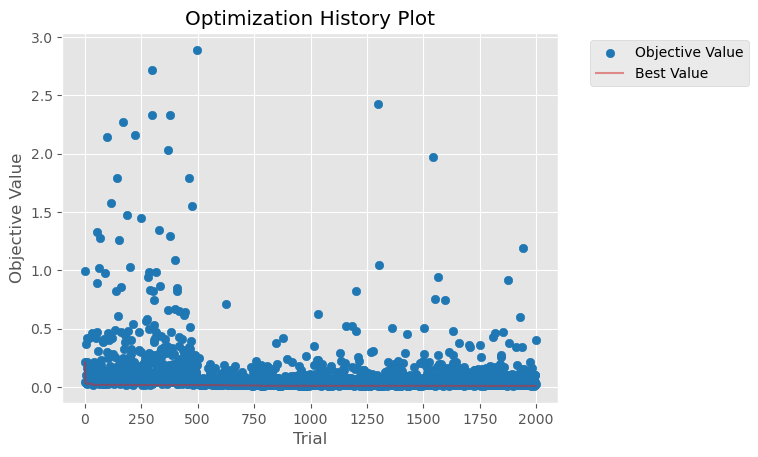

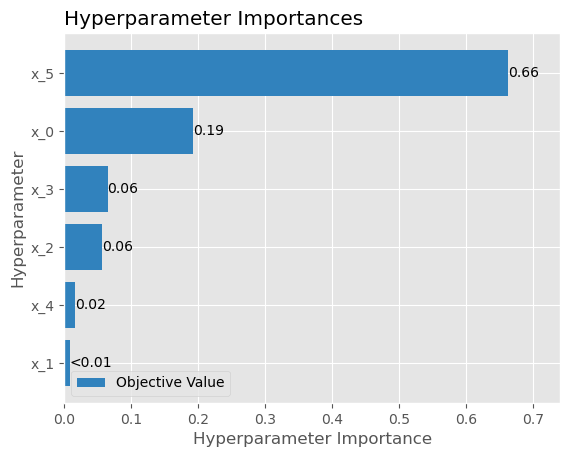

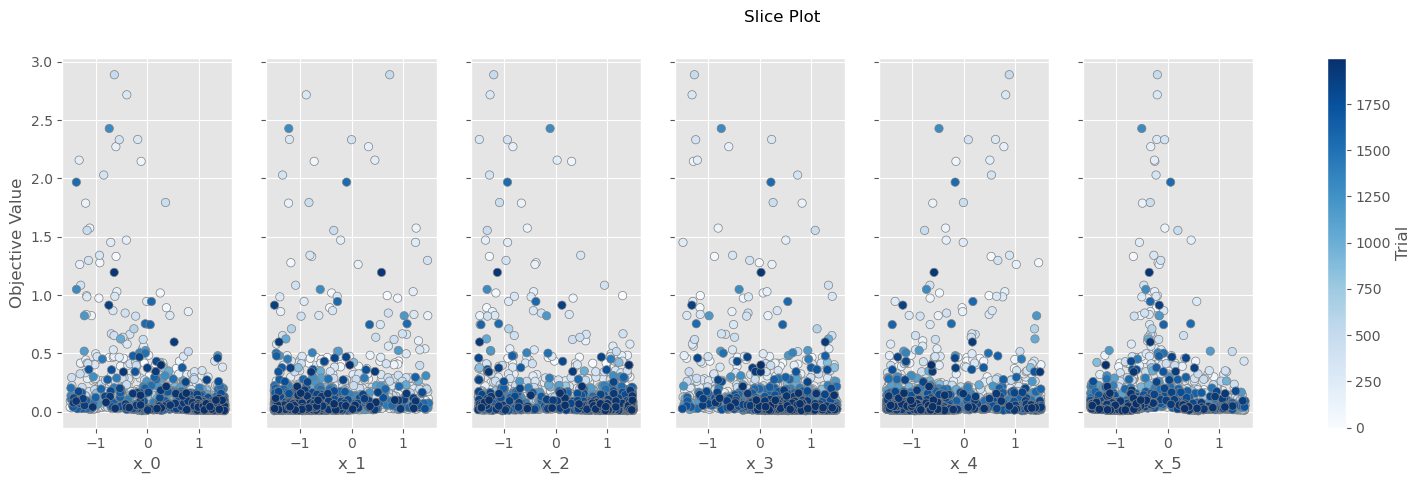

In [6]:
ax1 = plot_optimization_history(study)
ax1.set_alpha(0.7)
ax2 = plot_param_importances(study)
ax3 = plot_slice(study)